# DBSCAN CUDA C++/nvcc - Benchmarks com datasets sinteticos e reais

Este notebook organiza os datasets do trabalho. A parte principal sao datasets sinteticos controlados, porque eles permitem variar densidade, ruido, forma geometrica e dimensao. Os datasets reais do `sklearn` ficam como validacao complementar.

Datasets reais pequenos nao sao bons benchmarks de GPU, pois tendem a subutilizar a placa. Ainda assim, eles ajudam a verificar se o fluxo de baseline, binario CUDA e metricas funciona fora de blobs artificiais.

In [1]:
# Diagnostico do ambiente do Colab.
# Ative GPU em: Ambiente de execucao > Alterar tipo de ambiente de execucao > GPU.
!nvidia-smi
!nvcc --version
!which nvprof || echo "nvprof nao encontrado"

Mon Jun  8 04:33:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import re
import math
import time
import shutil
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.datasets import make_blobs, make_moons, load_iris, load_wine, load_breast_cancer, load_digits
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

SEED = 42
np.random.seed(SEED)
os.makedirs("results", exist_ok=True)

HAS_CUML = False
cp = None
CuMLDBSCAN = None

try:
    import cupy as cp
    from cuml.cluster import DBSCAN as CuMLDBSCAN
    HAS_CUML = True
    print("RAPIDS/cuML disponivel. Baseline: cuML.")
except Exception as exc:
    print("RAPIDS/cuML nao disponivel. Fallback do baseline: sklearn CPU.")
    print("Motivo:", repr(exc))

print("HAS_CUML:", HAS_CUML)

RAPIDS/cuML disponivel. Baseline: cuML.
HAS_CUML: True


In [3]:
def normalize_minmax(X):
    X = np.asarray(X, dtype=np.float32)
    mn = X.min(axis=0)
    mx = X.max(axis=0)
    denom = mx - mn
    denom[denom == 0.0] = 1.0
    return ((X - mn) / denom).astype(np.float32)


def estimate_eps(X, min_samples=8, quantile=0.90):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    return float(np.quantile(dists[:, -1], quantile))


def relabel_consecutive(labels):
    labels = np.asarray(labels, dtype=np.int32)
    out = np.full(labels.shape, -1, dtype=np.int32)
    valid = [int(v) for v in np.unique(labels) if int(v) != -1]
    for new, old in enumerate(sorted(valid)):
        out[labels == old] = new
    return out


def count_clusters(labels):
    labels = np.asarray(labels)
    values = set(labels.tolist())
    values.discard(-1)
    return len(values)


def noise_percent(labels):
    return 100.0 * float(np.mean(np.asarray(labels) == -1))


def run_baseline_dbscan(X, eps, min_samples):
    X = np.ascontiguousarray(X.astype(np.float32))
    start = time.time()
    if HAS_CUML:
        X_gpu = cp.asarray(X)
        model = CuMLDBSCAN(eps=float(eps), min_samples=int(min_samples))
        labels_gpu = model.fit_predict(X_gpu)
        cp.cuda.Stream.null.synchronize()
        labels = cp.asnumpy(labels_gpu).astype(np.int32)
        backend = "cuML"
    else:
        model = SklearnDBSCAN(eps=float(eps), min_samples=int(min_samples), n_jobs=-1)
        labels = model.fit_predict(X).astype(np.int32)
        backend = "sklearn_cpu"
    elapsed = time.time() - start
    return relabel_consecutive(labels), elapsed, backend


def print_table(df, title):
    print(title)
    print(df.where(pd.notna(df), "N/A").to_string(index=False))


def plot_2d(X, labels, title):
    if X.shape[1] == 2:
        X2 = X[:, :2]
        xlab, ylab = "x1", "x2"
    else:
        X2 = PCA(n_components=2, random_state=SEED).fit_transform(X)
        xlab, ylab = "PCA1", "PCA2"
    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=8, cmap="tab20", alpha=0.85, linewidths=0)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.tight_layout()
    plt.show()


def parse_key_values_stdout(stdout):
    metrics = {}
    for key, value in re.findall(r"([A-Za-z0-9_]+)=([^\s]+)", stdout):
        clean = value.strip().rstrip(",")
        try:
            if re.fullmatch(r"[-+]?\d+", clean):
                metrics[key] = int(clean)
            else:
                metrics[key] = float(clean)
        except ValueError:
            metrics[key] = clean
    return metrics


def run_cuda_binary(cmd):
    start = time.time()
    completed = subprocess.run(cmd, check=True, capture_output=True, text=True)
    wall_time = time.time() - start
    return completed.stdout, wall_time


def make_controlled_dataset(name, n_samples, seed=SEED, n_features_32d=32):
    rng = np.random.default_rng(seed)
    if name == "dense_blobs_2d":
        X, y = make_blobs(
            n_samples=n_samples,
            centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)],
            cluster_std=0.18,
            random_state=seed,
        )
    elif name == "heterogeneous_blobs_2d":
        n1 = int(0.45 * n_samples)
        n2 = int(0.35 * n_samples)
        n3 = n_samples - n1 - n2
        X1, _ = make_blobs(n_samples=n1, centers=[(-4, 0)], cluster_std=0.08, random_state=seed + 1)
        X2, _ = make_blobs(n_samples=n2, centers=[(0, 0)], cluster_std=0.25, random_state=seed + 2)
        X3, _ = make_blobs(n_samples=n3, centers=[(4, 0)], cluster_std=0.65, random_state=seed + 3)
        X = np.vstack([X1, X2, X3])
        y = np.concatenate([
            np.zeros(n1, dtype=np.int32),
            np.ones(n2, dtype=np.int32),
            np.full(n3, 2, dtype=np.int32),
        ])
    elif name == "dense_blobs_noise_2d":
        n_noise = int(0.20 * n_samples)
        n_blob = n_samples - n_noise
        X_blob, y_blob = make_blobs(
            n_samples=n_blob,
            centers=[(-3, -3), (-3, 3), (3, -3), (3, 3)],
            cluster_std=0.20,
            random_state=seed,
        )
        noise = rng.uniform(low=-5.5, high=5.5, size=(n_noise, 2))
        X = np.vstack([X_blob, noise])
        y = np.concatenate([y_blob.astype(np.int32), np.full(n_noise, -1, dtype=np.int32)])
    elif name == "moons_2d":
        X, y = make_moons(n_samples=n_samples, noise=0.045, random_state=seed)
    elif name == "blobs_32d":
        X, y = make_blobs(
            n_samples=n_samples,
            centers=6,
            n_features=n_features_32d,
            cluster_std=0.45,
            random_state=seed,
        )
    else:
        raise ValueError(name)
    return normalize_minmax(X), np.asarray(y, dtype=np.int32)


def dataset_record(nome, X, y, min_samples, descricao, objetivo):
    X = np.ascontiguousarray(normalize_minmax(X).astype(np.float32))
    eps = estimate_eps(X, min_samples=min_samples, quantile=0.90)
    return {
        "X": X,
        "y_true": np.asarray(y, dtype=np.int32),
        "eps": eps,
        "min_samples": int(min_samples),
        "descricao": descricao,
        "objetivo": objetivo,
        "n_pontos": int(X.shape[0]),
        "n_dimensoes": int(X.shape[1]),
    }


def build_synthetic_datasets(n_samples=4000, min_samples=8, seed=SEED):
    specs = {
        "dense_blobs_2d": ("Blobs 2D densos", "Testar gargalo com muitos core points."),
        "heterogeneous_blobs_2d": ("Blobs 2D com densidades diferentes", "Testar regioes com densidades diferentes."),
        "dense_blobs_noise_2d": ("Blobs 2D densos com ruido/outliers", "Testar ruido e pontos fora dos clusters."),
        "moons_2d": ("Duas luas 2D", "Testar formato nao convexo."),
        "blobs_32d": ("Blobs com 32 dimensoes", "Testar quantizacao e leitura de memoria."),
    }
    out = {}
    for name, (descricao, objetivo) in specs.items():
        X, y = make_controlled_dataset(name, n_samples, seed=seed)
        out[name] = dataset_record(name, X, y, min_samples, descricao, objetivo)
    return out


def build_real_datasets(min_samples=8):
    raw = {
        "real_iris_4d": (load_iris(), "Iris", "Validacao complementar pequena."),
        "real_wine_13d": (load_wine(), "Wine", "Validacao complementar com 13 dimensoes."),
        "real_breast_cancer_30d": (load_breast_cancer(), "Breast Cancer", "Validacao complementar com 30 dimensoes."),
        "real_digits_64d": (load_digits(), "Digits", "Validacao complementar com 64 dimensoes."),
    }
    out = {}
    for name, (data, descricao, objetivo) in raw.items():
        out[name] = dataset_record(name, data.data, data.target, min_samples, descricao, objetivo)
    return out


def datasets_summary_frame(collection):
    rows = []
    for name, item in collection.items():
        rows.append({
            "nome": name,
            "descricao": item["descricao"],
            "shape": str(item["X"].shape),
            "eps": item["eps"],
            "min_samples": item["min_samples"],
            "objetivo": item["objetivo"],
            "n_pontos": item["n_pontos"],
            "n_dimensoes": item["n_dimensoes"],
        })
    return pd.DataFrame(rows)

In [4]:
RUN_MODE = "quick"
N_SAMPLES = 4000 if RUN_MODE == "quick" else 12000
MIN_SAMPLES = 8

datasets = build_synthetic_datasets(n_samples=N_SAMPLES, min_samples=MIN_SAMPLES)
real_datasets = build_real_datasets(min_samples=MIN_SAMPLES)
all_datasets = {**datasets, **real_datasets}

df_sinteticos = datasets_summary_frame(datasets)
df_reais = datasets_summary_frame(real_datasets)
df_resumo = pd.concat([
    df_sinteticos.assign(tipo="sintetico"),
    df_reais.assign(tipo="real_complementar"),
], ignore_index=True)

output_csv = "results/resumo_datasets.csv"
df_resumo.to_csv(output_csv, index=False)
print_table(df_resumo.round(6), "Resumo dos datasets")
print("CSV salvo em:", output_csv)

Resumo dos datasets
                  nome                          descricao      shape      eps  min_samples                                  objetivo  n_pontos  n_dimensoes              tipo
        dense_blobs_2d                    Blobs 2D densos  (4000, 2) 0.009272            8    Testar gargalo com muitos core points.      4000            2         sintetico
heterogeneous_blobs_2d Blobs 2D com densidades diferentes  (4000, 2) 0.019447            8 Testar regioes com densidades diferentes.      4000            2         sintetico
  dense_blobs_noise_2d Blobs 2D densos com ruido/outliers  (4000, 2) 0.051632            8  Testar ruido e pontos fora dos clusters.      4000            2         sintetico
              moons_2d                       Duas luas 2D  (4000, 2) 0.015537            8               Testar formato nao convexo.      4000            2         sintetico
             blobs_32d             Blobs com 32 dimensoes (4000, 32) 0.185309            8  Testar quantizacao

In [5]:
# Celula separada para escolher o dataset ativo.
DATASET_NAME = "dense_blobs_2d"

item = all_datasets[DATASET_NAME]
X = np.ascontiguousarray(item["X"].astype(np.float32))
y_true = item["y_true"]
EPS = float(item["eps"])
MIN_SAMPLES = int(item["min_samples"])
N, D = X.shape

INPUT_BIN = "dbscan_dataset_ativo_f32.bin"
X.tofile(INPUT_BIN)

print("Dataset ativo:", DATASET_NAME)
print("Descricao:", item["descricao"])
print("Objetivo:", item["objetivo"])
print("Shape:", X.shape)
print("eps:", EPS)
print("min_samples:", MIN_SAMPLES)
print("Arquivo binario salvo:", INPUT_BIN)

Dataset ativo: dense_blobs_2d
Descricao: Blobs 2D densos
Objetivo: Testar gargalo com muitos core points.
Shape: (4000, 2)
eps: 0.009272272581687014
min_samples: 8
Arquivo binario salvo: dbscan_dataset_ativo_f32.bin


## Execucao CUDA no dataset ativo

A celula abaixo usa o mesmo binario do notebook de drop de core points. Isso permite testar rapidamente como o custo muda quando o dataset e denso, heterogeneo, com ruido, nao convexo, de alta dimensao ou real complementar.

In [6]:
%%writefile dbscan_drop_core.cu
#include <stdio.h>
#include <stdlib.h>
#include <stdint.h>
#include <math.h>
#include <fstream>
#include <vector>
#include <string>

#define CUDA_CHECK(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

__device__ unsigned int hash_u32(unsigned int x) {
    x ^= x >> 16;
    x *= 0x7feb352dU;
    x ^= x >> 15;
    x *= 0x846ca68bU;
    x ^= x >> 16;
    return x;
}

__device__ int find_root(int* parent, int i) {
    int root = i;
    while (root != parent[root]) root = parent[root];
    return root;
}

__global__ void find_cores(const float* X, int* is_core, int* neighbor_counts, int n, int d, float eps_sq, int min_pts) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    int neighbors = 0;
    for (int j = 0; j < n; j++) {
        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }
        if (dist_sq <= eps_sq) {
            neighbors++;
            if (neighbors >= min_pts) break;
        }
    }
    neighbor_counts[i] = neighbors;
    is_core[i] = (neighbors >= min_pts) ? 1 : 0;
}

__global__ void init_keep_and_parent(const int* is_core, int* keep_core, int* parent, int n, int keep_per_million, unsigned int seed) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    parent[i] = i;
    int keep = 0;
    if (is_core[i]) {
        if (keep_per_million >= 1000000) {
            keep = 1;
        } else {
            unsigned int h = hash_u32((unsigned int)i ^ seed);
            keep = ((int)(h % 1000000U) < keep_per_million) ? 1 : 0;
        }
    }
    keep_core[i] = keep;
}

__global__ void connect_cores(const float* X, const int* keep_core, int* parent, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n || !keep_core[i]) return;

    for (int j = i + 1; j < n; j++) {
        if (!keep_core[j]) continue;

        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }

        if (dist_sq <= eps_sq) {
            int root_i = find_root(parent, i);
            int root_j = find_root(parent, j);
            while (root_i != root_j) {
                if (root_i < root_j) {
                    int old = atomicCAS(&parent[root_j], root_j, root_i);
                    if (old == root_j) break;
                    root_j = find_root(parent, old);
                } else {
                    int old = atomicCAS(&parent[root_i], root_i, root_j);
                    if (old == root_i) break;
                    root_i = find_root(parent, old);
                }
            }
        }
    }
}

__global__ void flatten_parents(int* parent, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    int root = i;
    while (root != parent[root]) root = parent[root];
    parent[i] = root;
}

__global__ void assign_borders_nearest(const float* X, const int* keep_core, const int* parent, int* labels, int n, int d, float eps_sq) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;

    if (keep_core[i]) {
        labels[i] = parent[i];
        return;
    }

    int best_label = -1;
    float best_dist_sq = eps_sq;
    int found = 0;

    for (int j = 0; j < n; j++) {
        if (!keep_core[j]) continue;

        float dist_sq = 0.0f;
        for (int f = 0; f < d; f++) {
            float diff = X[i * d + f] - X[j * d + f];
            dist_sq += diff * diff;
            if (dist_sq > eps_sq) break;
        }

        if (dist_sq <= eps_sq && (!found || dist_sq < best_dist_sq)) {
            found = 1;
            best_dist_sq = dist_sq;
            best_label = parent[j];
        }
    }
    labels[i] = best_label;
}

int main(int argc, char** argv) {
    if (argc < 9) {
        printf("Usage: %s input.bin output_labels.bin n d eps min_pts keep_per_million seed\n", argv[0]);
        return 1;
    }

    std::string input_path = argv[1];
    std::string output_path = argv[2];
    int n = atoi(argv[3]);
    int d = atoi(argv[4]);
    float eps = (float)atof(argv[5]);
    int min_pts = atoi(argv[6]);
    int keep_per_million = atoi(argv[7]);
    unsigned int seed = (unsigned int)atoi(argv[8]);
    float eps_sq = eps * eps;

    size_t data_count = (size_t)n * (size_t)d;
    std::vector<float> h_X(data_count);
    std::ifstream in(input_path, std::ios::binary);
    if (!in) { printf("Could not open input file.\n"); return 1; }
    in.read((char*)h_X.data(), data_count * sizeof(float));
    in.close();

    float* d_X = nullptr;
    int *d_is_core = nullptr, *d_keep_core = nullptr, *d_parent = nullptr, *d_labels = nullptr, *d_neighbor_counts = nullptr;

    CUDA_CHECK(cudaMalloc(&d_X, data_count * sizeof(float)));
    CUDA_CHECK(cudaMalloc(&d_is_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_keep_core, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_parent, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_labels, n * sizeof(int)));
    CUDA_CHECK(cudaMalloc(&d_neighbor_counts, n * sizeof(int)));
    CUDA_CHECK(cudaMemcpy(d_X, h_X.data(), data_count * sizeof(float), cudaMemcpyHostToDevice));

    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    cudaEvent_t e0, e1, e2, e3, e4, e5;
    cudaEventCreate(&e0); cudaEventCreate(&e1); cudaEventCreate(&e2); cudaEventCreate(&e3); cudaEventCreate(&e4); cudaEventCreate(&e5);

    cudaEventRecord(e0);
    find_cores<<<blocks, threads>>>(d_X, d_is_core, d_neighbor_counts, n, d, eps_sq, min_pts);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e1);

    init_keep_and_parent<<<blocks, threads>>>(d_is_core, d_keep_core, d_parent, n, keep_per_million, seed);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e2);

    connect_cores<<<blocks, threads>>>(d_X, d_keep_core, d_parent, n, d, eps_sq);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e3);

    flatten_parents<<<blocks, threads>>>(d_parent, n);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e4);

    assign_borders_nearest<<<blocks, threads>>>(d_X, d_keep_core, d_parent, d_labels, n, d, eps_sq);
    CUDA_CHECK(cudaDeviceSynchronize());
    cudaEventRecord(e5);
    cudaEventSynchronize(e5);

    float ms_find=0, ms_init=0, ms_connect=0, ms_flatten=0, ms_assign=0;
    cudaEventElapsedTime(&ms_find, e0, e1);
    cudaEventElapsedTime(&ms_init, e1, e2);
    cudaEventElapsedTime(&ms_connect, e2, e3);
    cudaEventElapsedTime(&ms_flatten, e3, e4);
    cudaEventElapsedTime(&ms_assign, e4, e5);

    std::vector<int> h_labels(n), h_is_core(n), h_keep_core(n);
    CUDA_CHECK(cudaMemcpy(h_labels.data(), d_labels, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_is_core.data(), d_is_core, n * sizeof(int), cudaMemcpyDeviceToHost));
    CUDA_CHECK(cudaMemcpy(h_keep_core.data(), d_keep_core, n * sizeof(int), cudaMemcpyDeviceToHost));

    int n_core = 0, n_keep = 0, n_noise = 0;
    for (int i = 0; i < n; i++) {
        n_core += h_is_core[i];
        n_keep += h_keep_core[i];
        if (h_labels[i] == -1) n_noise++;
    }

    std::ofstream out(output_path, std::ios::binary);
    out.write((char*)h_labels.data(), n * sizeof(int));
    out.close();

    printf("n=%d d=%d eps=%f min_pts=%d keep_per_million=%d\n", n, d, eps, min_pts, keep_per_million);
    printf("core_points=%d kept_core_points=%d noise=%d\n", n_core, n_keep, n_noise);
    printf("time_find=%.6f time_init=%.6f time_connect=%.6f time_flatten=%.6f time_assign=%.6f total=%.6f seconds\n",
           ms_find/1000.0f, ms_init/1000.0f, ms_connect/1000.0f, ms_flatten/1000.0f, ms_assign/1000.0f,
           (ms_find + ms_init + ms_connect + ms_flatten + ms_assign)/1000.0f);

    cudaFree(d_X); cudaFree(d_is_core); cudaFree(d_keep_core); cudaFree(d_parent); cudaFree(d_labels); cudaFree(d_neighbor_counts);
    return 0;
}

Writing dbscan_drop_core.cu


In [7]:
!nvcc dbscan_drop_core.cu -o dbscan_drop_core -O3

!if command -v nvprof >/dev/null 2>&1; then nvprof ./dbscan_drop_core {INPUT_BIN} nvprof_dataset_keep100_labels.bin {N} {D} {EPS} {MIN_SAMPLES} 1000000 {SEED}; else echo "nvprof nao encontrado; executando binario diretamente"; ./dbscan_drop_core {INPUT_BIN} nvprof_dataset_keep100_labels.bin {N} {D} {EPS} {MIN_SAMPLES} 1000000 {SEED}; fi

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
==844== NVPROF is profiling process 844, command: ./dbscan_drop_core dbscan_dataset_ativo_f32.bin nvprof_dataset_keep100_labels.bin 4000 2 0.009272272581687014 8 1000000 42
n=4000 d=2 eps=0.009272 min_pts=8 keep_per_million=1000000
core_points=3600 kept_core_points=3600 noise=227
time_find=0.165190 time_init=0.000045 time_connect=0.003811 time_flatten=0.000047 time_assign=0.001738 total=0.170830 seconds
==844== Profiling application: ./dbscan_drop_core dbscan_dataset_ativo_f32.bin nvprof_dataset_keep100_labels.bin 4000 2 0.009272272581687014 8 1000000 42
==844== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   54.08%  3.7708ms         1  3.7708ms  3.7708ms  3.7708ms  connect_cores(float const *, int const *, int*, int, int, float)
  

In [8]:
labels_baseline, time_baseline, backend = run_baseline_dbscan(X, EPS, MIN_SAMPLES)
baseline_version = f"baseline_{backend}"
results = [{
    "versao": baseline_version,
    "dataset": DATASET_NAME,
    "keep_ratio_target": 1.0,
    "keep_ratio_real": np.nan,
    "core_points": np.nan,
    "kept_core_points": np.nan,
    "noise_%": noise_percent(labels_baseline),
    "time_s_wall": time_baseline,
    "total_cuda_event_s": np.nan,
    "time_connect": np.nan,
    "clusters": count_clusters(labels_baseline),
    "ARI_vs_baseline": 1.0,
    "NMI_vs_baseline": 1.0,
}]
all_labels = {baseline_version: labels_baseline}

for version, ratio in [
    ("cuda_cpp_keep_100", 1.00),
    ("cuda_cpp_drop_keep_75", 0.75),
    ("cuda_cpp_drop_keep_50", 0.50),
    ("cuda_cpp_drop_keep_25", 0.25),
]:
    out_file = f"{DATASET_NAME}_{version}_labels.bin"
    keep_per_million = int(round(ratio * 1_000_000))
    cmd = ["./dbscan_drop_core", INPUT_BIN, out_file, str(N), str(D), str(EPS), str(MIN_SAMPLES), str(keep_per_million), str(SEED)]
    stdout, wall_time = run_cuda_binary(cmd)
    print("\n---", version, "---")
    print(stdout)
    metrics = parse_key_values_stdout(stdout)
    labels = relabel_consecutive(np.fromfile(out_file, dtype=np.int32, count=N))
    all_labels[version] = labels
    core_points = int(metrics.get("core_points", 0))
    kept_core_points = int(metrics.get("kept_core_points", 0))
    results.append({
        "versao": version,
        "dataset": DATASET_NAME,
        "keep_ratio_target": ratio,
        "keep_ratio_real": kept_core_points / core_points if core_points else np.nan,
        "core_points": core_points,
        "kept_core_points": kept_core_points,
        "noise_%": noise_percent(labels),
        "time_s_wall": wall_time,
        "total_cuda_event_s": float(metrics.get("total", np.nan)),
        "time_connect": float(metrics.get("time_connect", np.nan)),
        "clusters": count_clusters(labels),
        "ARI_vs_baseline": adjusted_rand_score(labels_baseline, labels),
        "NMI_vs_baseline": normalized_mutual_info_score(labels_baseline, labels),
    })

df_results = pd.DataFrame(results)
output_csv = f"results/resultados_dataset_ativo_{DATASET_NAME}.csv"
df_results.to_csv(output_csv, index=False)
print_table(df_results.round(4), "Resultados no dataset ativo")
print("CSV salvo em:", output_csv)


--- cuda_cpp_keep_100 ---
n=4000 d=2 eps=0.009272 min_pts=8 keep_per_million=1000000
core_points=3600 kept_core_points=3600 noise=227
time_find=0.001973 time_init=0.000024 time_connect=0.004262 time_flatten=0.000030 time_assign=0.001923 total=0.008212 seconds


--- cuda_cpp_drop_keep_75 ---
n=4000 d=2 eps=0.009272 min_pts=8 keep_per_million=750000
core_points=3600 kept_core_points=2652 noise=244
time_find=0.001165 time_init=0.000028 time_connect=0.001772 time_flatten=0.000020 time_assign=0.001024 total=0.004009 seconds


--- cuda_cpp_drop_keep_50 ---
n=4000 d=2 eps=0.009272 min_pts=8 keep_per_million=500000
core_points=3600 kept_core_points=1741 noise=283
time_find=0.001262 time_init=0.000024 time_connect=0.001287 time_flatten=0.000020 time_assign=0.000811 total=0.003405 seconds


--- cuda_cpp_drop_keep_25 ---
n=4000 d=2 eps=0.009272 min_pts=8 keep_per_million=250000
core_points=3600 kept_core_points=864 noise=352
time_find=0.001065 time_init=0.000022 time_connect=0.000865 time_flatte

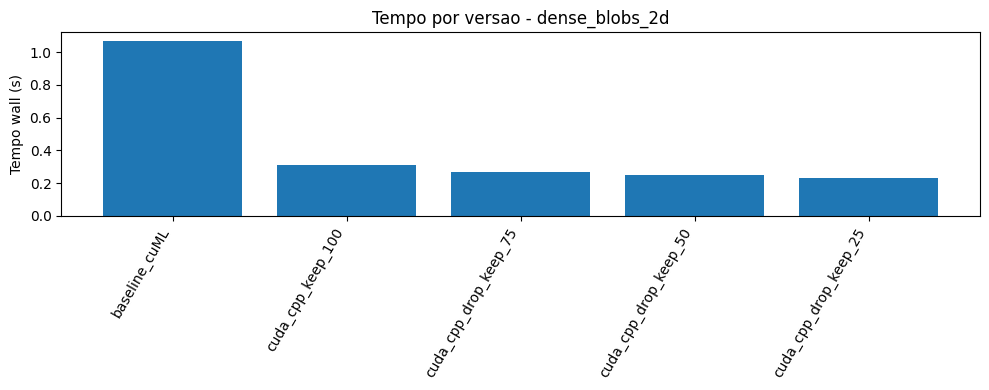

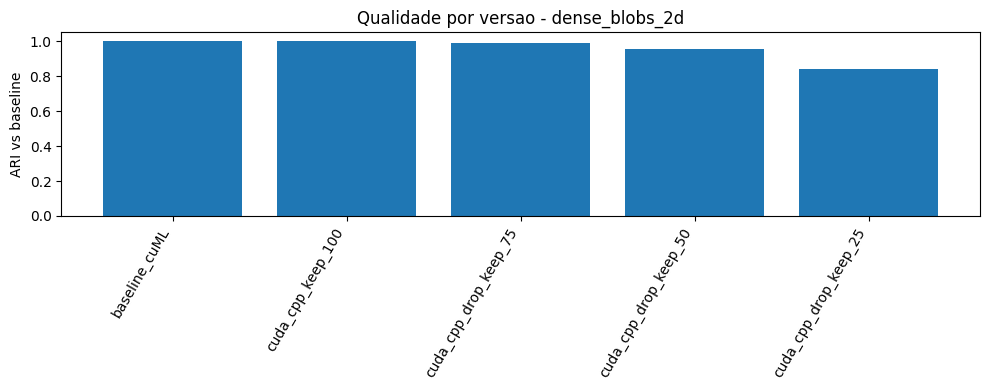

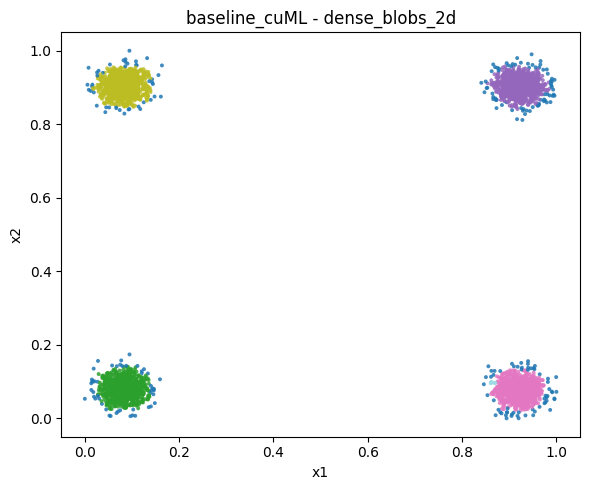

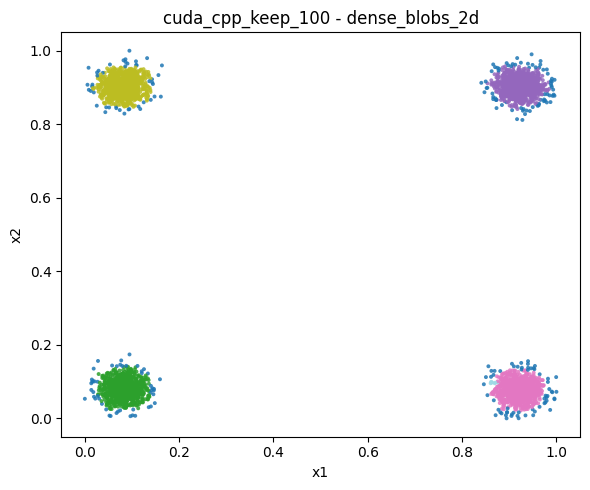

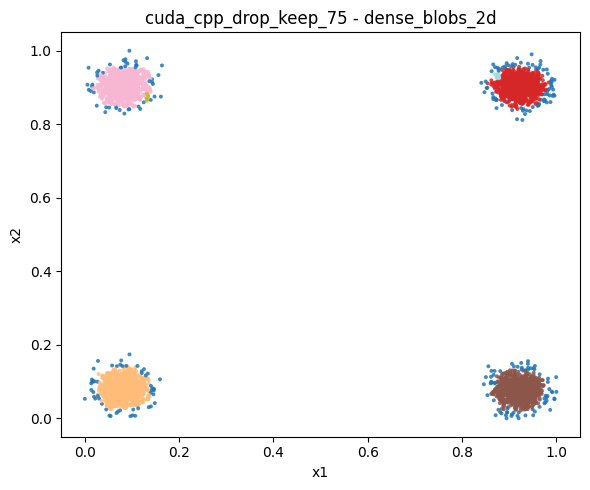

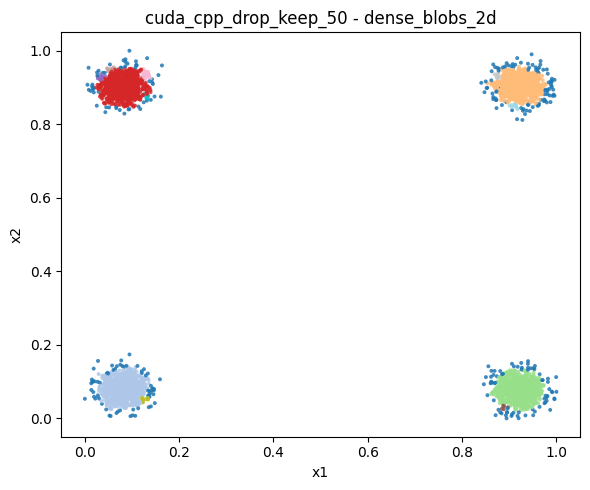

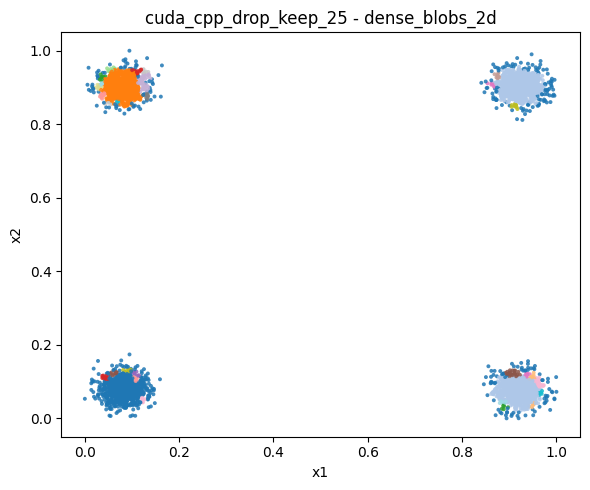

In [9]:
plt.figure(figsize=(10, 4))
plt.bar(df_results["versao"], df_results["time_s_wall"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Tempo wall (s)")
plt.title(f"Tempo por versao - {DATASET_NAME}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(df_results["versao"], df_results["ARI_vs_baseline"])
plt.xticks(rotation=60, ha="right")
plt.ylim(0, 1.05)
plt.ylabel("ARI vs baseline")
plt.title(f"Qualidade por versao - {DATASET_NAME}")
plt.tight_layout()
plt.show()

for name, labels in all_labels.items():
    plot_2d(X, labels, f"{name} - {DATASET_NAME}")

## Leitura esperada

Use `dense_blobs_2d` para evidenciar o gargalo de muitos core points, `heterogeneous_blobs_2d` para discutir densidades diferentes, `dense_blobs_noise_2d` para ruido/outliers, `moons_2d` para formato nao convexo e `blobs_32d` para cenarios em que leitura de memoria e quantizacao ficam mais relevantes. Os datasets reais devem ser tratados como validacao complementar, nao como prova de desempenho de GPU.